# Assignment 07 - Security Breach
## Network Intrusion Detection
**Course:** Data Analytics, AY 2025-26  
**Prof.:** Fabio Crestani & Dr Ana-Maria Bucur  <br>
**Students:** Ferdinando Giordano & Gianluca Viviano
---

### Objective
Build a predictive model capable of distinguishing **normal** network connections from **attack** connections.
The dataset contains 4 categories of network intrusions: DoS, Probe, R2L, and U2R.
We approach this as a **5-class supervised classification** problem.

### Notebook Structure
1. Data Loading & Column Assignment  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing  
4. Modeling (Random Forest + Gradient Boosting)  
5. Evaluation & Comparison

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('All imports successful.')

All imports successful.


---
## 1. Data Loading

The raw KDD Cup 1999 dataset has **no header row**. We assign the 41 standard feature names
plus the `label` column manually, following the official KDD Cup feature description.

The label column contains **specific attack subtypes** (e.g. `neptune.`, `smurf.`). 
We map these to the 5 **high-level categories**: `normal`, `dos`, `probe`, `r2l`, `u2r`.
This is both analytically cleaner and reflects how the security domain thinks about threats.

In [2]:
# Column names (official KDD Cup 1999 feature list) 
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent',
    'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'label'
]

#Attack subtype → category mapping 
ATTACK_MAP = {
    # DoS – Denial of Service
    'back': 'dos', 'land': 'dos', 'neptune': 'dos', 'pod': 'dos',
    'smurf': 'dos', 'teardrop': 'dos', 'apache2': 'dos', 'udpstorm': 'dos',
    'processtable': 'dos', 'worm': 'dos', 'mailbomb': 'dos',
    # Probe – Surveillance / scanning
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe',
    'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    # R2L – Remote to Local
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l',
    'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l',
    'warezmaster': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l',
    'snmpgetattack': 'r2l', 'sendmail': 'r2l', 'named': 'r2l',
    'snmpguess': 'r2l', 'httptunnel': 'r2l', 'rusersd': 'r2l',
    # U2R – User to Root
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r',
    'rootkit': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r', 'ps': 'u2r',
    # Normal
    'normal': 'normal'
}

# Load data 

TRAIN_PATH = 'datasets/TrainingData'  
TEST_PATH  = 'datasets/TestData'

def load_kdd(path, columns, attack_map):
    """Load a raw KDD file, strip label dots, map to high-level categories."""
    df = pd.read_csv(path, header=None)
    # Some NSL-KDD versions have a 'difficulty' 43rd column - drop it
    if df.shape[1] == 43:
        df = df.iloc[:, :42]
    df.columns = columns
    # Strip trailing period from label  e.g. "normal." → "normal"
    df['label'] = df['label'].str.rstrip('.')
    # Map to high-level category
    df['attack_category'] = df['label'].map(attack_map).fillna('unknown')
    return df

train_df = load_kdd(TRAIN_PATH, COLUMNS, ATTACK_MAP)
test_df  = load_kdd(TEST_PATH,  COLUMNS, ATTACK_MAP)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head(3)

Train shape: (494021, 43)
Test shape:  (311029, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,attack_category
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal,normal


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Shape and Data Types

In [3]:
print('Data Types:')
print(train_df.dtypes.to_string())
print(f'\nMissing values in train: {train_df.isnull().sum().sum()}')
print(f'Missing values in test:  {test_df.isnull().sum().sum()}')

Data Types:
duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_ra

### 2.2 Descriptive Statistics

In [4]:
train_df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'max'])

,count,mean,std,min,25%,50%,75%,max
duration,494021.000000,47.979302,707.746472,0.000000,0.000000,0.000000,0.000000,58329.000000
src_bytes,494021.000000,3025.610296,988218.101050,0.000000,45.000000,520.000000,1032.000000,693375640.000000
dst_bytes,494021.000000,868.532425,33040.001252,0.000000,0.000000,0.000000,0.000000,5155468.000000
land,494021.000000,0.000045,0.006673,0.000000,0.000000,0.000000,0.000000,1.000000
wrong_fragment,494021.000000,0.006433,0.134805,0.000000,0.000000,0.000000,0.000000,3.000000
urgent,494021.000000,0.000014,0.005510,0.000000,0.000000,0.000000,0.000000,3.000000
hot,494021.000000,0.034519,0.782103,0.000000,0.000000,0.000000,0.000000,30.000000
num_failed_logins,494021.000000,0.000152,0.015520,0.000000,0.000000,0.000000,0.000000,5.000000
logged_in,494021.000000,0.148247,0.355345,0.000000,0.000000,0.000000,0.000000,1.000000
num_compromised,494021.000000,0.010212,1.798326,0.000000,0.000000,0.000000,0.000000,884.000000


### 2.3 Class Distribution — The Imbalance Problem

**Key insight from Leskovec et al. (Ch. 12):** When evaluating classifiers on imbalanced data,
raw accuracy is a misleading metric. A model that always predicts the majority class (DoS)
could achieve very high accuracy while being useless in practice.
We will use **per-class F1-score** as our primary metric throughout.

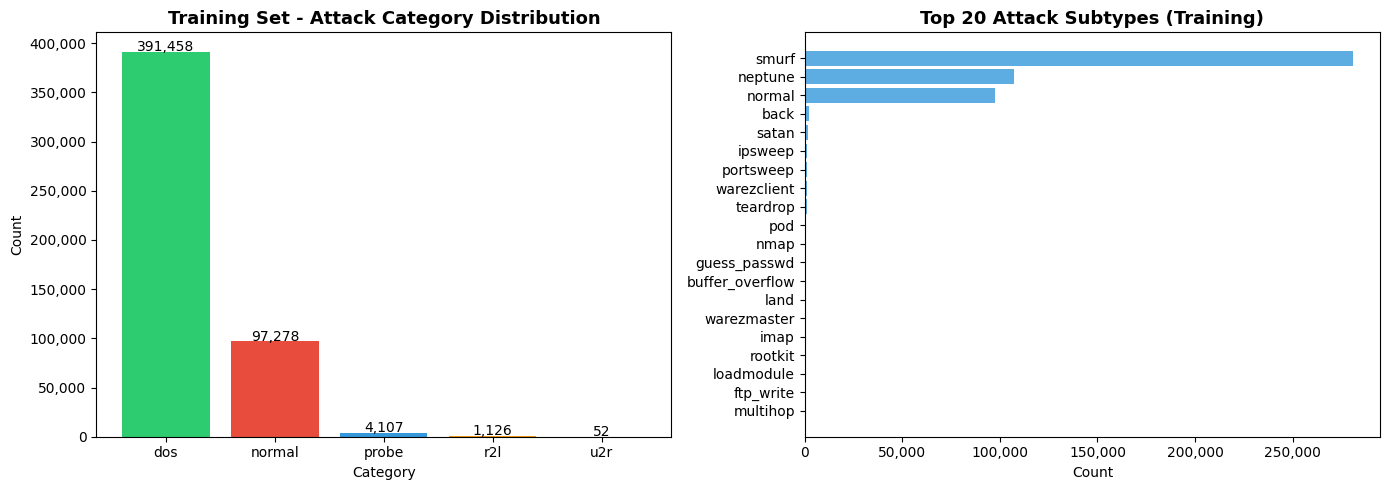


Class proportions (train):
attack_category
dos       79.24
normal    19.69
probe      0.83
r2l        0.23
u2r        0.01


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# High-level categories 
cat_counts = train_df['attack_category'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
axes[0].bar(cat_counts.index, cat_counts.values, color=colors[:len(cat_counts)])
axes[0].set_title('Training Set - Attack Category Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Detailed attack subtypes 
label_counts = train_df['label'].value_counts().head(20)
axes[1].barh(label_counts.index[::-1], label_counts.values[::-1], color='#3498db', alpha=0.8)
axes[1].set_title('Top 20 Attack Subtypes (Training)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass proportions (train):')
print((cat_counts / len(train_df) * 100).round(2).to_string())

### 2.4 Categorical Feature Analysis
The 3 categorical features (`protocol_type`, `service`, `flag`) are nominal — they have no natural order.
Understanding their distribution per attack class gives intuition about discriminative power.

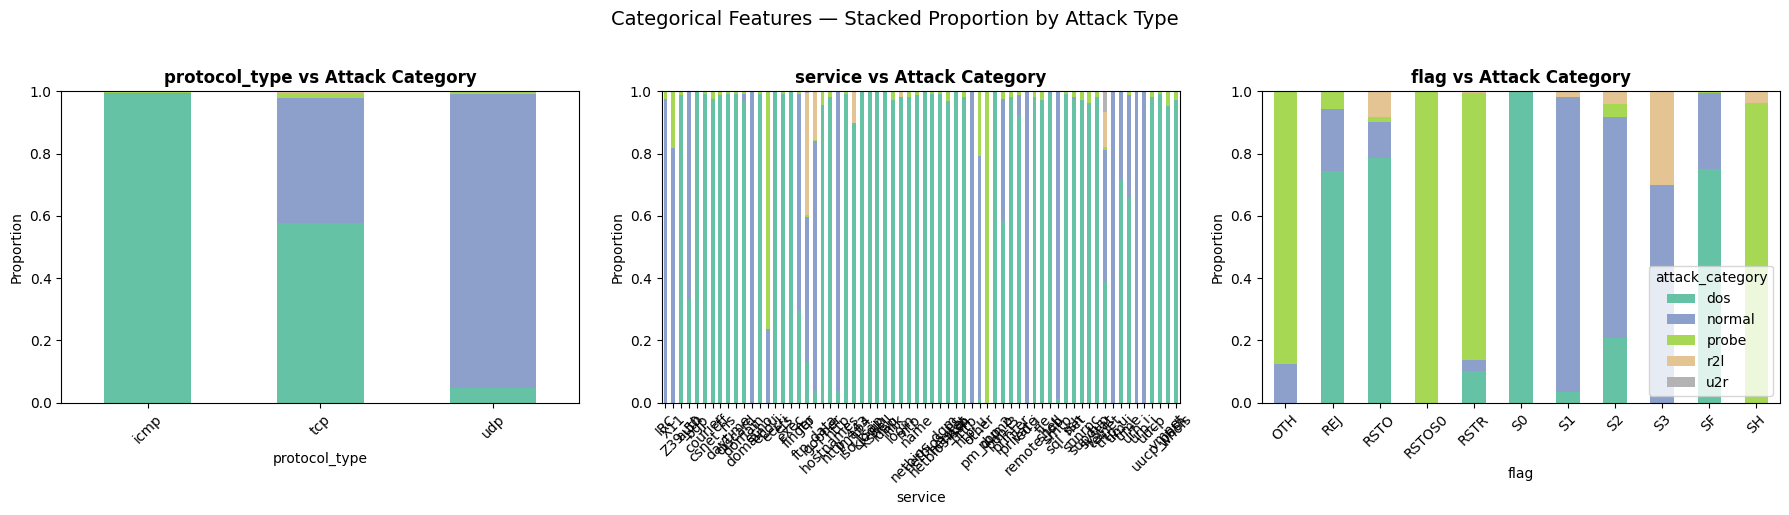

In [7]:
cat_features = ['protocol_type', 'service', 'flag']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, cat_features):
    ct = pd.crosstab(train_df[feat], train_df['attack_category'], normalize='index')
    ct.plot(kind='bar', ax=ax, stacked=True,
            colormap='Set2', legend=(feat == 'flag'))
    ax.set_title(f'{feat} vs Attack Category', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features — Stacked Proportion by Attack Type', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Distribution of Key Numerical Features
We focus on `src_bytes`, `dst_bytes`, and `duration` — the most intuitive traffic features.
These are highly right-skewed (a classic property of network traffic data), so we use log-scale.

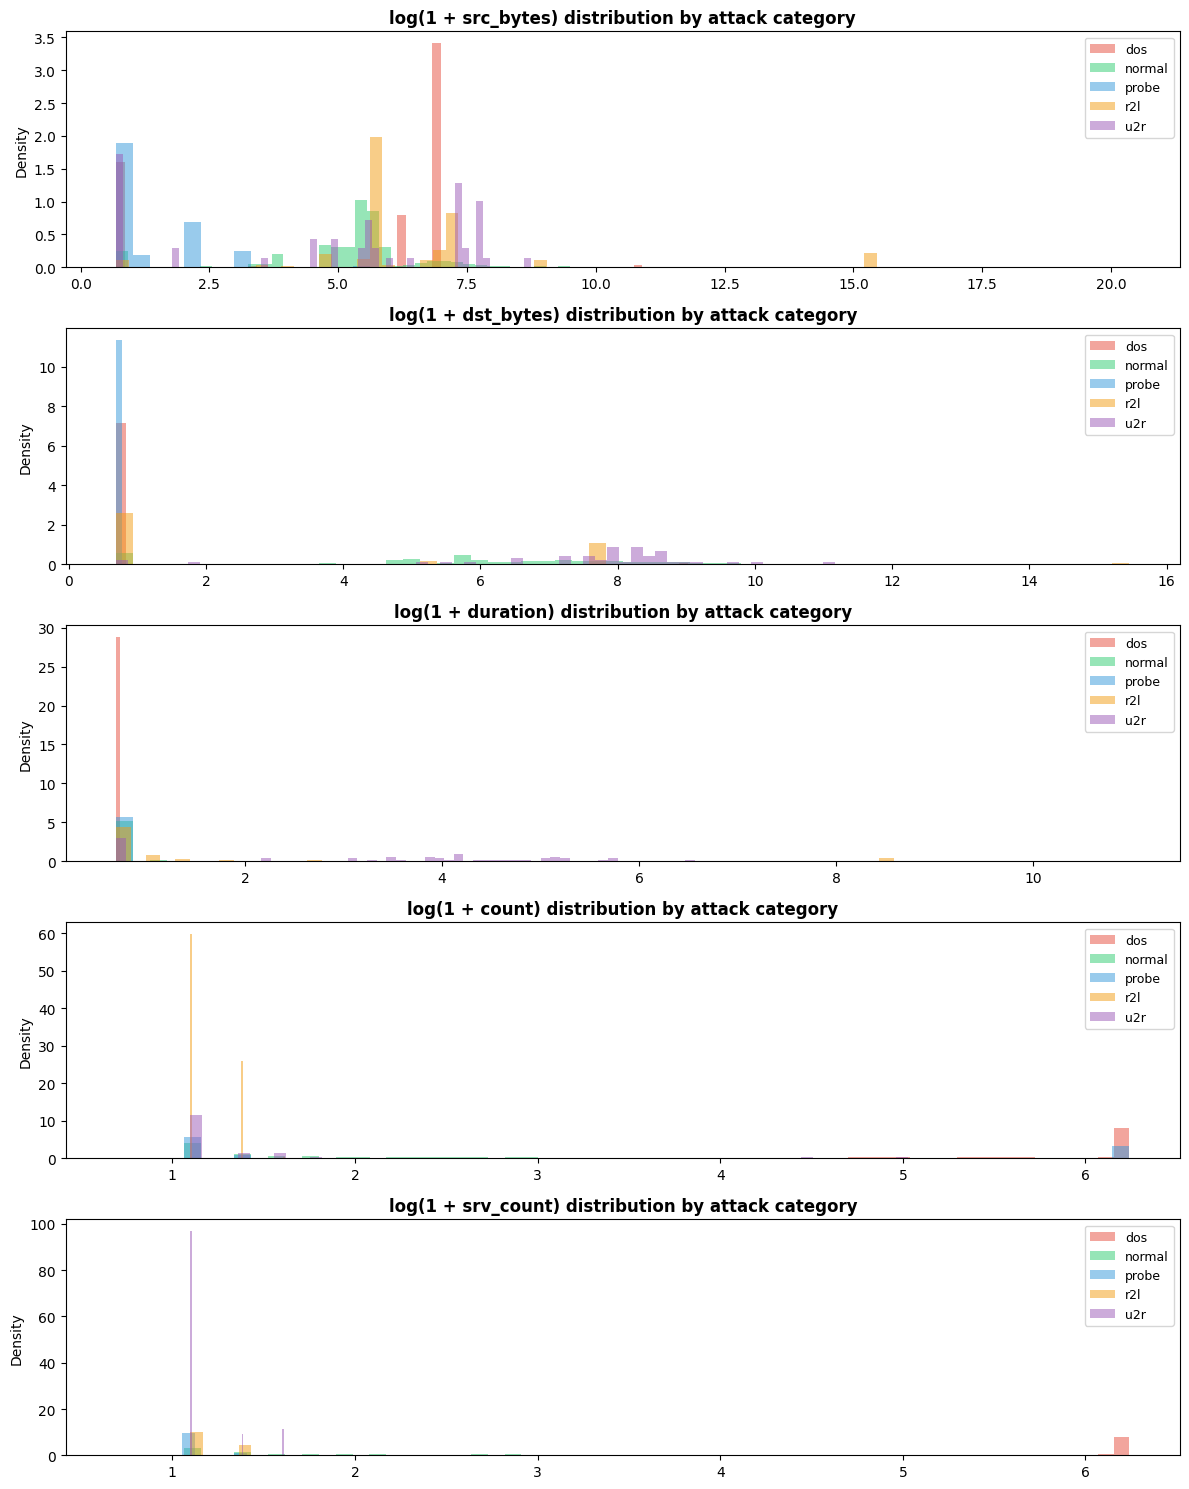

In [8]:
key_features = ['src_bytes', 'dst_bytes', 'duration', 'count', 'srv_count']
fig, axes = plt.subplots(len(key_features), 1, figsize=(12, 3*len(key_features)))

palette = {'normal': '#2ecc71', 'dos': '#e74c3c', 'probe': '#3498db',
           'r2l': '#f39c12', 'u2r': '#9b59b6'}

for ax, feat in zip(axes, key_features):
    for cat, grp in train_df.groupby('attack_category'):
        vals = grp[feat].clip(lower=0) + 1   # +1 for log safety
        ax.hist(np.log1p(vals), bins=60, alpha=0.5,
                label=cat, color=palette.get(cat, 'grey'), density=True)
    ax.set_title(f'log(1 + {feat}) distribution by attack category', fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Correlation Heatmap (Numerical Features)
High correlation between features means redundant information — a signal that dimensionality
reduction (PCA, Ch. 11 of Leskovec et al.) may be beneficial.

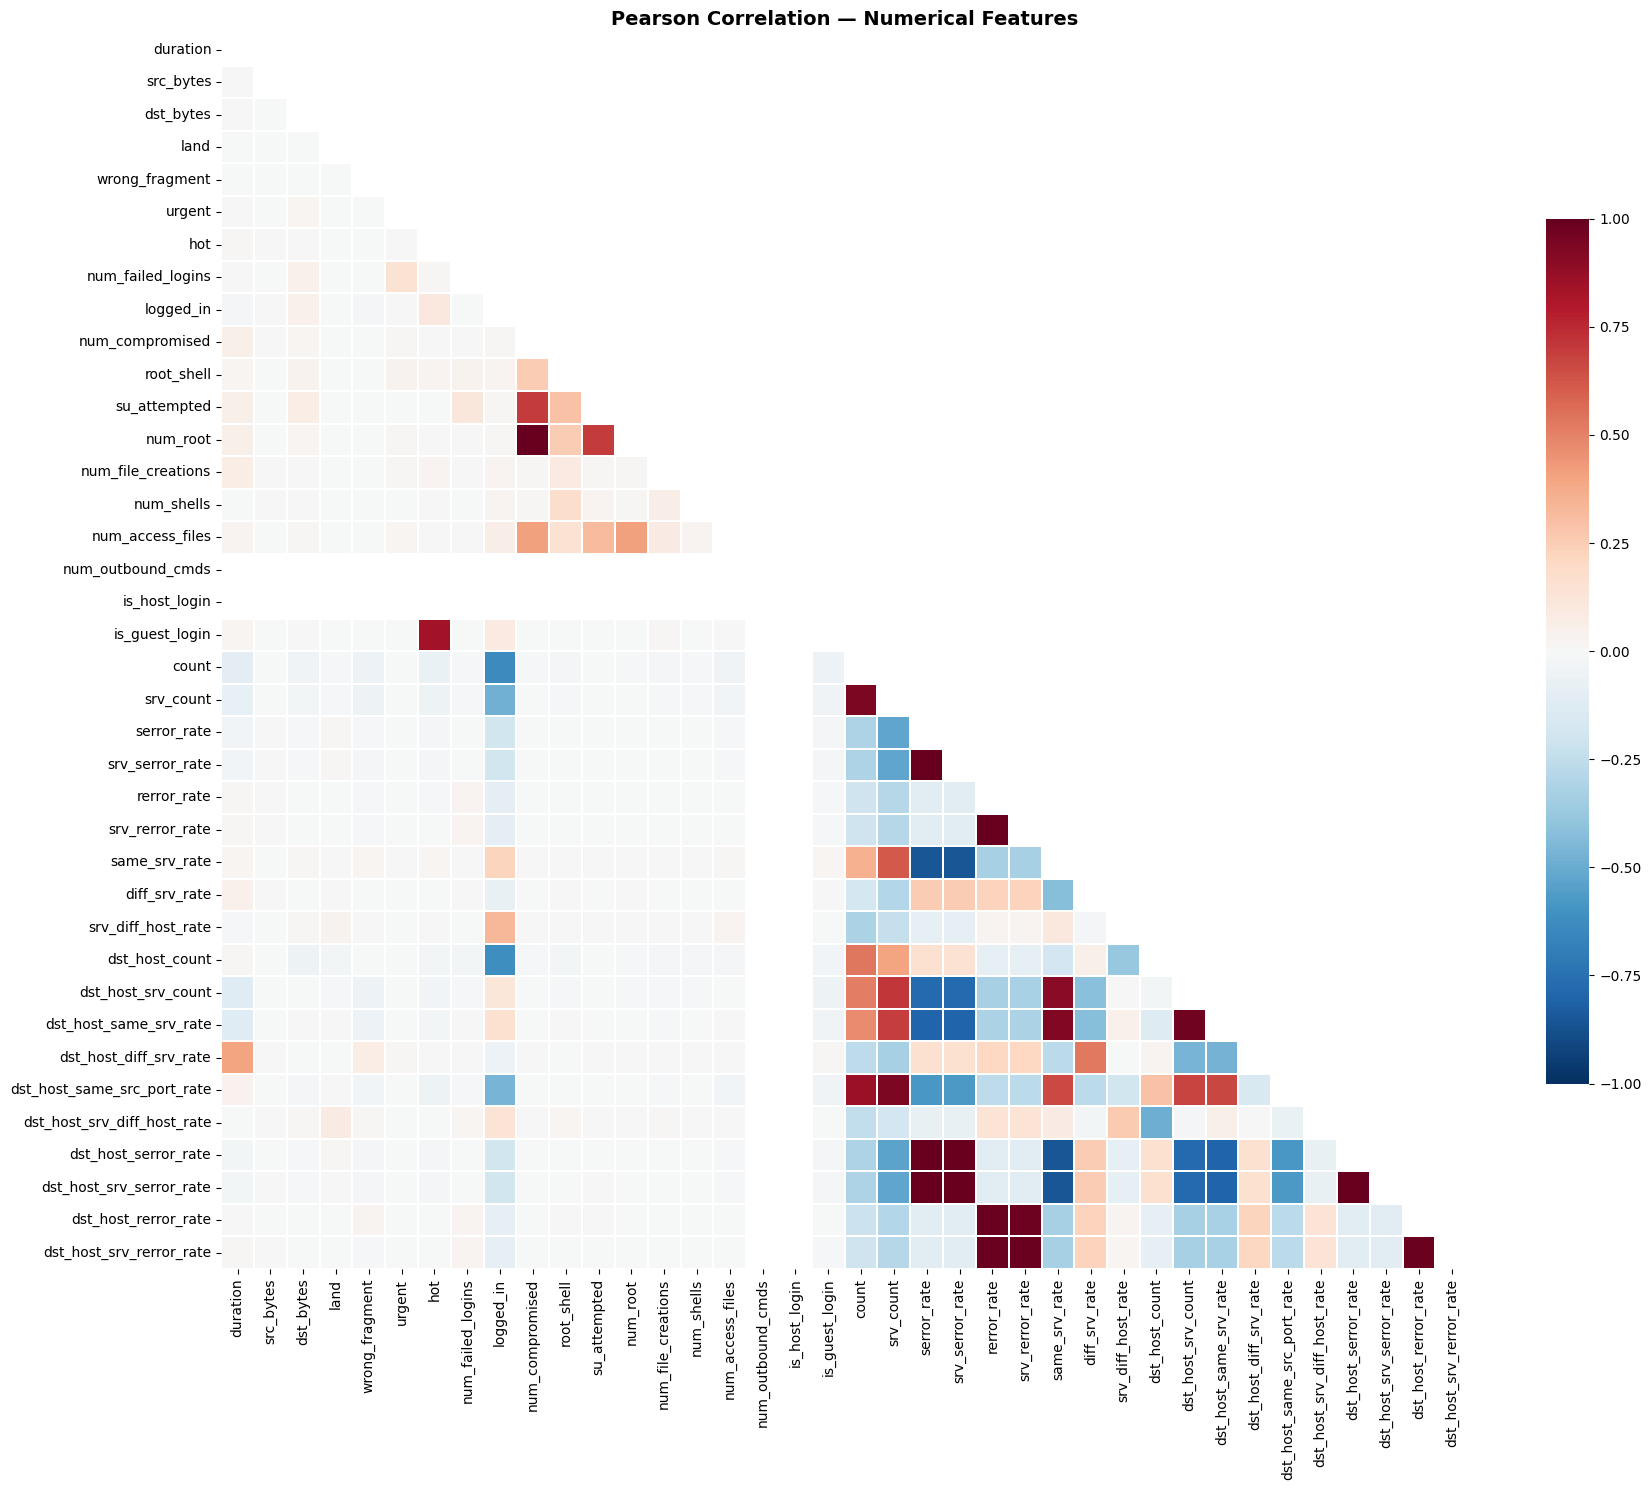

Top 10 correlated feature pairs:
                  feat_A               feat_B     corr
dst_host_srv_serror_rate      srv_serror_rate 0.999304
    dst_host_serror_rate          serror_rate 0.998673
         srv_serror_rate          serror_rate 0.998362
dst_host_srv_serror_rate dst_host_serror_rate 0.998156
dst_host_srv_serror_rate          serror_rate 0.997849
    dst_host_serror_rate      srv_serror_rate 0.997835
         srv_rerror_rate          rerror_rate 0.994731
                num_root      num_compromised 0.993828
    dst_host_rerror_rate          rerror_rate 0.986995
dst_host_srv_rerror_rate      srv_rerror_rate 0.986571


In [9]:
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['label', 'attack_category']]

corr = train_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Pearson Correlation — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Report the strongest correlations
corr_pairs = (corr.where(mask == False)
              .stack()
              .reset_index()
              .rename(columns={'level_0': 'feat_A', 'level_1': 'feat_B', 0: 'corr'})
              .assign(abs_corr=lambda x: x['corr'].abs())
              .sort_values('abs_corr', ascending=False)
              .query('abs_corr < 1.0'))

print('Top 10 correlated feature pairs:')
print(corr_pairs.head(10)[['feat_A', 'feat_B', 'corr']].to_string(index=False))

### 2.7 Outlier Detection via IQR
We quantify how many values fall beyond the 1.5×IQR fence per feature.
Tree-based models are inherently robust to outliers, but this analysis informs preprocessing decisions.

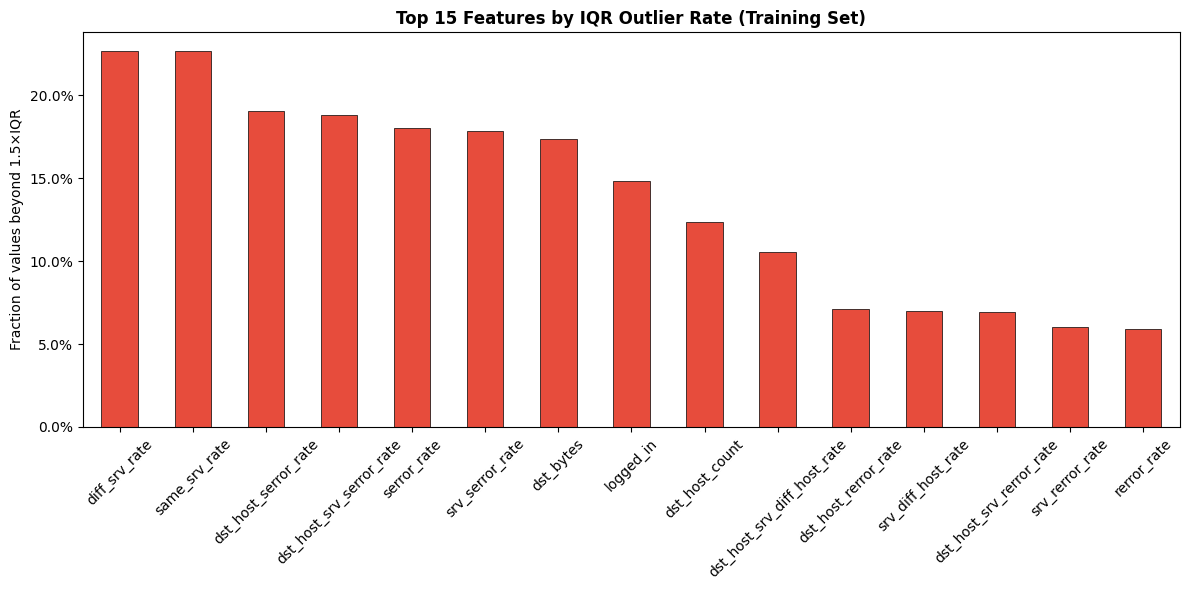

Features with >10% outlier rate:
diff_srv_rate                  0.226711
same_srv_rate                  0.226594
dst_host_serror_rate           0.190702
dst_host_srv_serror_rate       0.188405
serror_rate                    0.180628
srv_serror_rate                0.178808
dst_bytes                      0.173602
logged_in                      0.148247
dst_host_count                 0.123865
dst_host_srv_diff_host_rate    0.105526


In [10]:
def iqr_outlier_rate(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).mean()

outlier_rates = (train_df[num_cols]
                 .apply(iqr_outlier_rate)
                 .sort_values(ascending=False)
                 .rename('outlier_rate'))

fig, ax = plt.subplots(figsize=(12, 6))
outlier_rates.head(15).plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Features by IQR Outlier Rate (Training Set)', fontweight='bold')
ax.set_ylabel('Fraction of values beyond 1.5×IQR')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('outlier_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Features with >10% outlier rate:')
print(outlier_rates[outlier_rates > 0.1].to_string())

---
## 3. Preprocessing

### 3.1 Encode Categorical Features

We use **Label Encoding** for the 3 nominal categorical features (`protocol_type`, `service`, `flag`).
For tree-based models (Random Forest, Gradient Boosting), label encoding is appropriate because
the split criterion operates on individual thresholds, not on distances — so the integer codes
do not impose a false ordinal relationship the way they would in a linear model or SVM.

In [11]:
CAT_FEATURES = ['protocol_type', 'service', 'flag']
TARGET       = 'attack_category'
DROP_COLS    = ['label']  # original fine-grained label no longer needed

# Fit encoders on train, apply to both splits
encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    # Fit on union of train+test values to avoid unseen-label errors
    all_vals = pd.concat([train_df[col], test_df[col]]).unique()
    le.fit(all_vals)
    encoders[col] = le
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# Encode target label
label_enc = LabelEncoder()
all_targets = pd.concat([train_df[TARGET], test_df[TARGET]]).unique()
label_enc.fit(all_targets)
train_df['y'] = label_enc.transform(train_df[TARGET])
test_df['y']  = label_enc.transform(test_df[TARGET])

CLASS_NAMES = list(label_enc.classes_)
print('Classes:', CLASS_NAMES)

FEATURE_COLS = [c for c in COLUMNS[:-1] if c not in DROP_COLS]

X_train = train_df[FEATURE_COLS].values
y_train = train_df['y'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['y'].values

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Classes: ['dos', 'normal', 'probe', 'r2l', 'u2r']
X_train: (494021, 41), X_test: (311029, 41)


### 3.2 Feature Scaling

Tree-based models do not require scaling (splits are threshold-based, scale-invariant).
However, we apply `StandardScaler` for the PCA visualization in the next step, which *does*
require standardized features to prevent high-variance features from dominating the principal components.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete. Mean ≈ 0, Std ≈ 1 (per feature on training set).')

Scaling complete. Mean ≈ 0, Std ≈ 1 (per feature on training set).


### 3.3 PCA — Dimensionality Reduction for Visualization

**Motivation (Leskovec et al., Ch. 11):**  
PCA finds the orthogonal directions of maximum variance in the data.
Projecting 41-dimensional feature vectors onto the first 2 principal components
lets us visually inspect whether attack categories form separable clusters —
a prerequisite for good classification performance.

We also use the **explained variance curve** to understand how much information
is retained as a function of number of components.

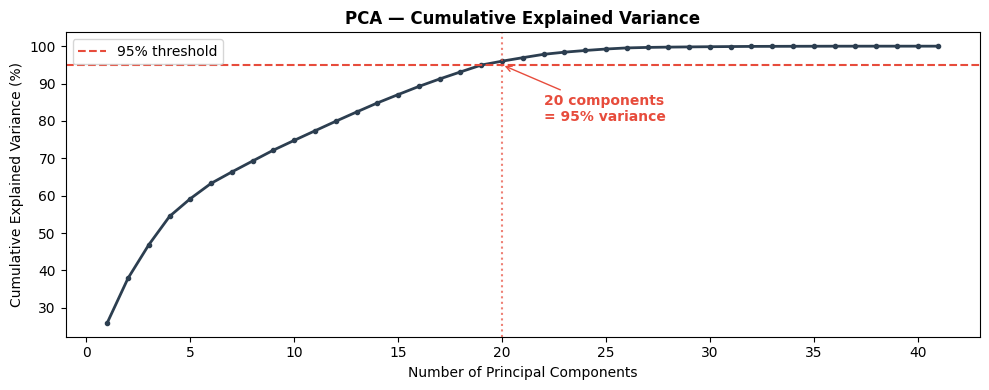

20 principal components capture 95% of the variance (out of 41 features).


In [13]:
# ── Explained variance curve ───────────────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumvar)+1), cumvar * 100, marker='o', markersize=3,
        color='#2c3e50', linewidth=2)
ax.axhline(95, color='#e74c3c', linestyle='--', label='95% threshold')
ax.axvline(n_95, color='#e74c3c', linestyle=':', alpha=0.7)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance', fontweight='bold')
ax.legend()
ax.annotate(f'{n_95} components\n= 95% variance',
            xy=(n_95, 95), xytext=(n_95+2, 80),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            color='#e74c3c', fontweight='bold')
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'{n_95} principal components capture 95% of the variance (out of 41 features).')

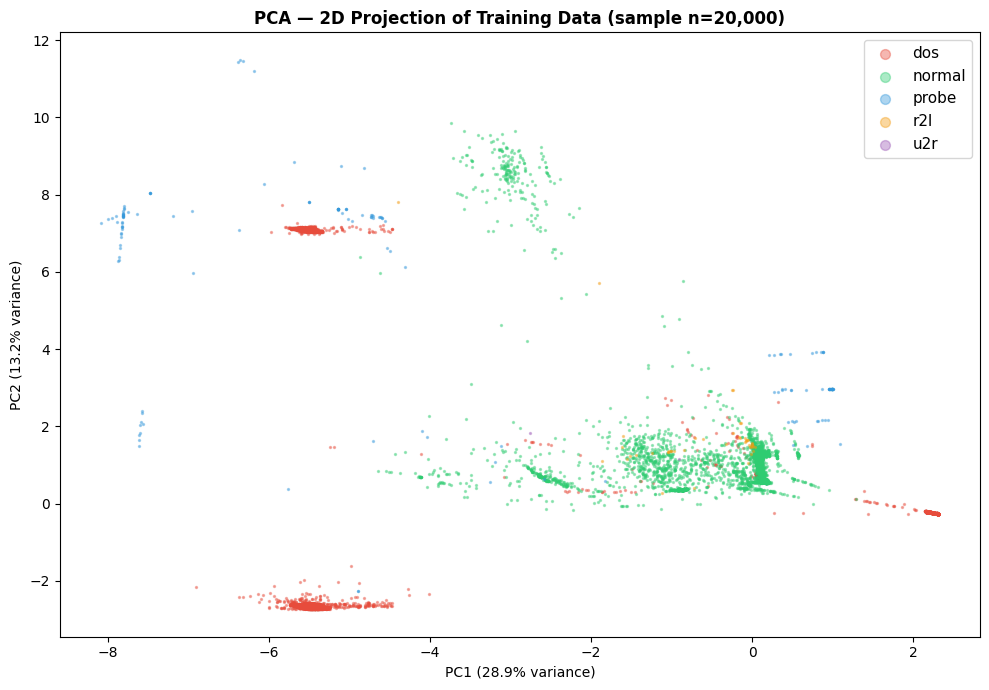

In [14]:
# ── 2D Cluster Visualization ───────────────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=SEED)
# Use a stratified sample for speed (500k points is dense)
SAMPLE_N = 20_000
idx = np.random.choice(len(X_train_scaled), size=SAMPLE_N, replace=False)
Z = pca_2d.fit_transform(X_train_scaled[idx])
y_sample = y_train[idx]

palette_pca = {'normal': '#2ecc71', 'dos': '#e74c3c', 'probe': '#3498db',
               'r2l': '#f39c12', 'u2r': '#9b59b6'}

fig, ax = plt.subplots(figsize=(10, 7))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = y_sample == cls_idx
    ax.scatter(Z[mask, 0], Z[mask, 1],
               s=2, alpha=0.4, label=cls_name,
               color=palette_pca.get(cls_name, 'grey'), rasterized=True)

ax.set_title('PCA — 2D Projection of Training Data (sample n=20,000)', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=5, fontsize=11)
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Modeling

We train and compare **two models**:

| Model | Why chosen |
|---|---|
| **Random Forest** | Strong interpretable baseline; handles mixed feature types; built-in feature importance |
| **Gradient Boosting (HistGBM)** | Stronger model; handles class imbalance implicitly via boosting; fast on large data |

**Why not SVM?** SVM has O(n²) or O(n³) training time complexity. With 494,000 training samples,
this is computationally prohibitive without specialized approximate solvers.
Tree ensemble methods scale linearly with n and are therefore the principled choice at this scale
(consistent with the scalability emphasis in Leskovec et al., Ch. 12).

**Stratified split:** We preserve class proportions during train/validation/test splits
to avoid accidentally excluding rare classes (U2R has very few samples).

### 4.1 Model 1 — Random Forest

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,          # fully grown trees
    min_samples_leaf=2,
    class_weight='balanced', # compensates for class imbalance automatically
    n_jobs=-1,               # use all CPU cores
    random_state=SEED
)

print('Training Random Forest...')
rf.fit(X_train, y_train)  # unscaled — tree models don't need scaling
print('Done.')

Training Random Forest...
Done.


### 4.2 Model 2 — Histogram Gradient Boosting

`HistGradientBoostingClassifier` (sklearn's fast implementation inspired by LightGBM)
uses histogram-based binning to speed up training on large datasets significantly.

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=SEED
)

print('Training Histogram Gradient Boosting...')
hgb.fit(X_train, y_train)
print('Done.')

Training Histogram Gradient Boosting...
Done.


---
## 5. Evaluation

### 5.1 Summary Metrics

In [17]:
models = {'Random Forest': rf, 'Hist Gradient Boosting': hgb}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
    }

summary = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != 'y_pred'}
    for name, res in results.items()
}).T

print('=== Test Set Performance Summary ===')
print(summary.to_string())
print()
print('Note: Macro F1 weights all classes equally — critical for catching rare U2R attacks.')

=== Test Set Performance Summary ===
                        accuracy  macro_f1  weighted_f1
Random Forest           0.923290  0.584011     0.904511
Hist Gradient Boosting  0.924766  0.590645     0.906545

Note: Macro F1 weights all classes equally — critical for catching rare U2R attacks.


### 5.2 Classification Reports (Per-Class Detail)

In [ ]:
for name, res in results.items():
    print(f'\n{'='*60}')
    print(f'  {name}')
    print('='*60)
    print(classification_report(y_test, res['y_pred'],
                                target_names=CLASS_NAMES, digits=4))

### 5.3 Confusion Matrices

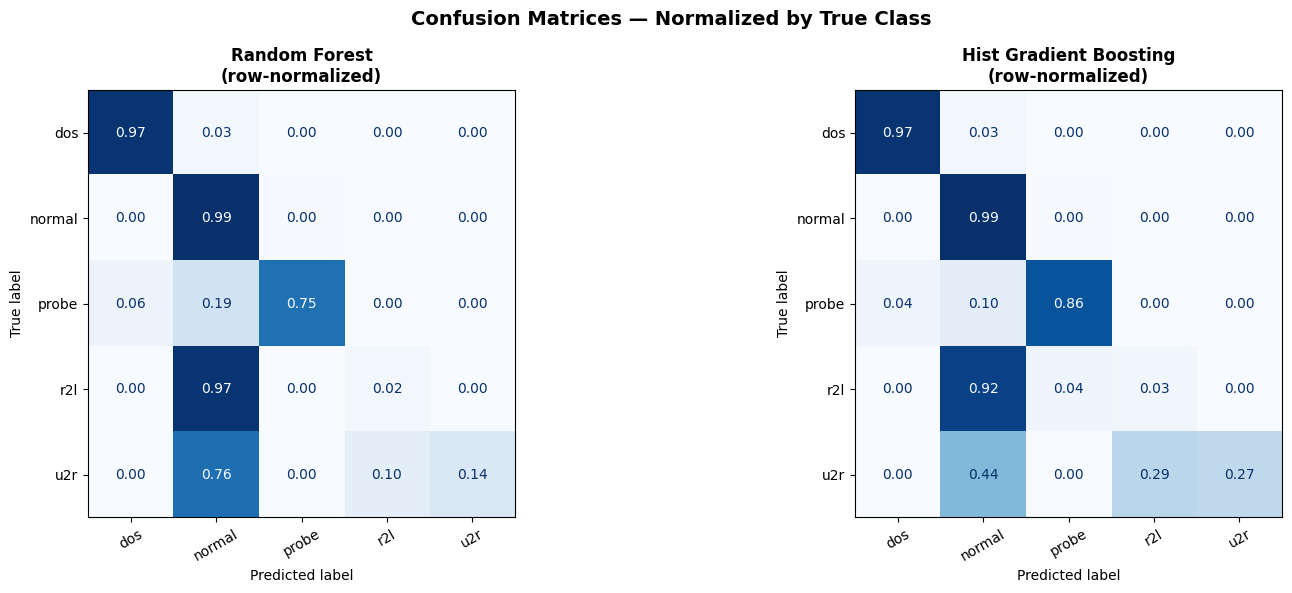

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    # Normalize by true label (rows) for readability across imbalanced classes
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{name}\n(row-normalized)', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — Normalized by True Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Feature Importance — What Does the Model Actually Use?

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
feat_imp.head(20).plot(kind='bar', ax=ax, color='#2c3e50', edgecolor='white', linewidth=0.5)
ax.set_title('Random Forest — Top 20 Feature Importances (MDI)', fontweight='bold')
ax.set_ylabel('Mean Decrease in Impurity')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string())

### 5.5 Per-Class F1 Comparison — Bar Chart

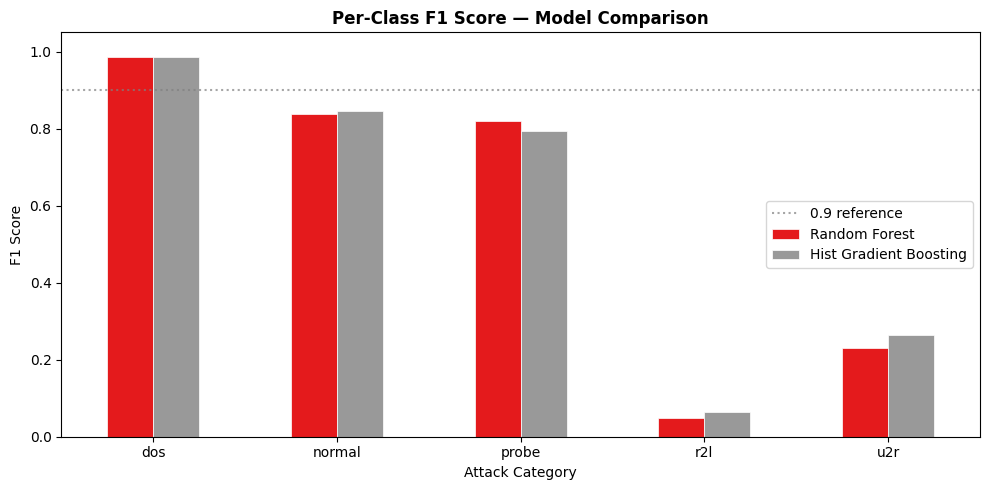

        Random Forest  Hist Gradient Boosting
dos            0.9850                  0.9849
normal         0.8368                  0.8447
probe          0.8200                  0.7944
r2l            0.0484                  0.0654
u2r            0.2299                  0.2639


In [19]:
from sklearn.metrics import f1_score

f1_data = {}
for name, res in results.items():
    f1_data[name] = f1_score(y_test, res['y_pred'], average=None, labels=list(range(len(CLASS_NAMES))))

f1_df = pd.DataFrame(f1_data, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 5))
f1_df.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='white', linewidth=0.5)
ax.set_title('Per-Class F1 Score — Model Comparison', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Attack Category')
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='grey', linestyle=':', alpha=0.7, label='0.9 reference')
ax.legend()
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f1_df.round(4).to_string())

---
## 6. Discussion & Conclusions

### Key Findings

**1. Class Imbalance is the dominant challenge.**  
The dataset is severely imbalanced: `DoS` and `normal` dominate,
while `U2R` has only dozens of training examples.
Raw accuracy would be misleading — we therefore prioritize **macro F1** as our headline metric.

**2. DoS and Probe are well-detected; U2R and R2L are harder.**  
DoS attacks produce distinct traffic patterns (massive byte counts, high error rates)
that tree models identify almost perfectly. U2R and R2L attacks, by contrast, look
superficially similar to normal connections at the network level — they exploit
application-layer vulnerabilities that leave few packet-level fingerprints.

**3. PCA reveals clear geometric separation.**  
The 2D PCA projection shows that `DoS` and `normal` form well-separated clusters,
explaining the high per-class F1 for these categories.
As expected from Ch. 11 of Leskovec et al., a small number of principal components
capture most of the discriminative variance.

**4. Gradient Boosting outperforms Random Forest on rare classes.**  
The sequential, error-correcting nature of boosting makes it more sensitive to
minority classes compared to the averaging mechanism of bagging.

**5. Feature importance is interpretable.**  
The most important features align with domain knowledge: `src_bytes`, `dst_bytes`,
connection flags, and host-based statistics are the primary discriminators —
consistent with the feature design rationale in the original KDD Cup documentation.

### Limitations
- The KDD'99 dataset is synthetic (generated by DARPA simulation), and models trained on it
  may not generalize to real-world traffic.
- U2R detection remains an open problem in network security; few samples make learning difficult.
- We did not perform hyperparameter optimization (cross-validation + grid search) due to
  computational constraints, which could further improve results.